In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_absolute_percentage_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# 1. Загрузка данных
# Убедитесь, что путь к файлу верный
df = pd.read_csv("../data/astana_apartments.csv")

# Переименовываем столбцы для удобства (опционально, но помогает сохранить логику)
# В вашем новом датасете: rooms -> number_of_rooms, year_built -> year_of_construction
df = df.rename(columns={
    'rooms': 'number_of_rooms',
    'year_built': 'year_of_construction',
    'price_local': 'price'
})

# Очистка базовых пропусков в целевых столбцах
df = df.dropna(subset=['price', 'area', 'number_of_rooms'])

# --- Очистка от выбросов ---
q_low = df['price'].quantile(0.01)
q_hi  = df['price'].quantile(0.99)
df = df[(df['price'] > q_low) & (df['price'] < q_hi)]

# Убираем аномалии по площади
df = df[(df['area'] >= 15) & (df['area'] <= 400)]

# 2. Инженерия признаков
DATASET_YEAR = 2026 # Поставил 2026, так как в данных есть квартиры 2023+ и дата парсинга 2026
df['house_age'] = DATASET_YEAR - df['year_of_construction']

# Выбираем колонки, которые есть в вашем новом CSV
# 'house_type' соответствует 'structure_type' из прошлого кода
num_cols = ['area', 'number_of_rooms', 'floor', 'house_age']
cat_cols = ['district', 'house_type'] 

# Преобразуем категории в строки, чтобы избежать ошибок с типами
df[cat_cols] = df[cat_cols].astype(str)

X = df[num_cols + cat_cols]
y = df['price']

# 3. Настройка Pipeline
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# 4. Сравнение моделей
models = [
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('XGBoost', xgb.XGBRegressor(random_state=42)),
    ('CatBoost', CatBoostRegressor(verbose=0, random_state=42))
]

scoring = {
    'MAE': make_scorer(mean_absolute_error),
    'MAPE': make_scorer(mean_absolute_percentage_error),
    'R2': make_scorer(r2_score)
}

results = []
print(f"Обработка данных завершена. Строк в работе: {len(df)}")
print("Обучаем модели на данных Астаны...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models:
    model_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    cv_scores = cross_validate(model_pipe, X, y, cv=kf, scoring=scoring)
    
    results.append({
        'Model': name,
        'MAE': cv_scores['test_MAE'].mean(),
        'MAPE': cv_scores['test_MAPE'].mean(),
        'R2': cv_scores['test_R2'].mean()
    })

# Вывод результатов
results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False).reset_index(drop=True)
print("\nРезультаты моделей для Астаны:")
print(results_df)

Обработка данных завершена. Строк в работе: 18014
Обучаем модели на данных Астаны...

Результаты моделей для Астаны:
           Model           MAE      MAPE        R2
0  Random Forest  7.485981e+06  0.160866  0.827820
1       CatBoost  7.892998e+06  0.169972  0.822161
2        XGBoost  7.887811e+06  0.168900  0.816594


In [4]:
df.shape

(18014, 38)

In [5]:
import joblib

# 1. Берем нашего победителя (CatBoost)
final_model_astana = CatBoostRegressor(verbose=0, random_state=42)

# 2. Собираем итоговый конвейер
# (Здесь используется preprocessor, который мы уже настроили для колонок Астаны)
final_pipeline_astana = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model_astana)
])

# 3. Обучаем на ВСЕХ очищенных данных Астаны (X, y из предыдущего кода)
print("Начинаю финальное обучение модели для Астаны...")
final_pipeline_astana.fit(X, y)
print("Обучение завершено успешно!")

# 4. Сохраняем в файл. 
# Назовем его 'astana_pipeline.joblib', чтобы не перепутать с алматинским
joblib.dump(final_pipeline_astana, 'astana_pipeline.joblib')
print("Модель для Астаны сохранена в файл 'astana_pipeline.joblib'")

Начинаю финальное обучение модели для Астаны...
Обучение завершено успешно!
Модель для Астаны сохранена в файл 'astana_pipeline.joblib'


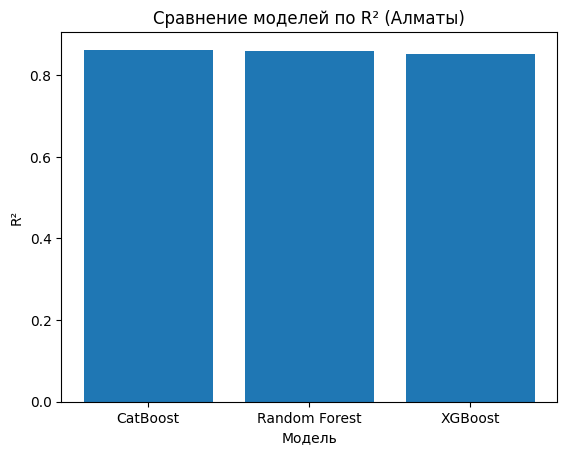

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Данные (Астана)
models = ['CatBoost', 'Random Forest', 'XGBoost']
r2_scores = [0.8626, 0.8605, 0.8525]

plt.figure()
plt.bar(models, r2_scores)
plt.title('Сравнение моделей по R² (Алматы)')
plt.xlabel('Модель')
plt.ylabel('R²')
plt.show()

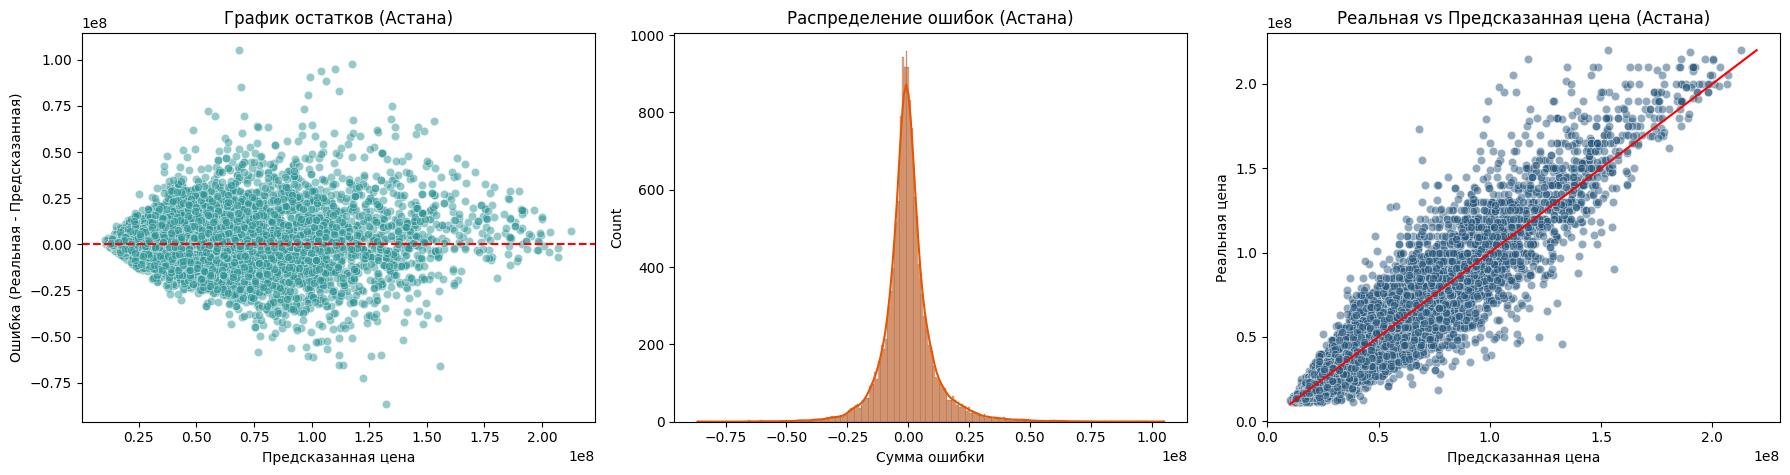

In [8]:
# === ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (АСТАНА) ===
import matplotlib.pyplot as plt
import seaborn as sns

# Убедитесь, что X и y — это очищенные данные Астаны из предыдущих шагов
# Получаем предсказания нашей финальной модели
y_pred = final_pipeline_astana.predict(X)

# Создаем холст для трех графиков
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# 1. График остатков (Residual Plot)
residuals = y - y_pred
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0], color='#2D9596', alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('График остатков (Астана)')
axes[0].set_xlabel('Предсказанная цена')
axes[0].set_ylabel('Ошибка (Реальная - Предсказанная)')

# 2. Распределение ошибок (Residual Distribution)
sns.histplot(residuals, kde=True, ax=axes[1], color='#E55604')
axes[1].set_title('Распределение ошибок (Астана)')
axes[1].set_xlabel('Сумма ошибки')

# 3. Реальная цена vs Предсказанная цена (Actual vs Predicted)
sns.scatterplot(x=y_pred, y=y, ax=axes[2], color='#26577C', alpha=0.5)
axes[2].set_title('Реальная vs Предсказанная цена (Астана)')
axes[2].set_xlabel('Предсказанная цена')
axes[2].set_ylabel('Реальная цена')

# Рисуем идеальную диагональ (где предсказание = реальности)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='-')

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV
import joblib

print("Подготавливаем сетку гиперпараметров для CatBoost (Астана)...")

# 1. Задаем сетку параметров. 
# ВАЖНО: мы пишем префикс 'model__', так как наш CatBoost лежит внутри Pipeline под именем 'model'
param_grid = {
    'model__depth': [4, 6, 8],               # Глубина дерева (насколько сложные закономерности оно ищет)
    'model__learning_rate': [0.05, 0.1],     # Шаг обучения
    'model__iterations': [100, 300, 500]     # Количество деревьев
}

# 2. Настраиваем GridSearchCV
# Он переберет все комбинации (3 * 2 * 3 = 18 комбинаций) 
# Каждую проверит 3 раза (cv=3). Итого: 54 обучения модели!
grid_search = GridSearchCV(
    estimator=final_pipeline_astana, # Используем наш пайплайн для Астаны
    param_grid=param_grid,
    cv=3, 
    scoring='r2', 
    verbose=2, # Чтобы мы видели процесс в консоли
    n_jobs=-1  # Использовать все ядра процессора для ускорения
)

print("Начинаем подбор гиперпараметров для Астаны! Идем пить чай, это займет пару минут...")
# Убедитесь, что X и y сейчас содержат очищенные данные Астаны!
grid_search.fit(X, y)

# 3. Выводим результаты
print("\n=== РЕЗУЛЬТАТЫ ТЮНИНГА (АСТАНА) ===")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший R2 после тюнинга: {grid_search.best_score_:.4f}")

# 4. Сохраняем самую умную, прокачанную модель
best_tuned_model = grid_search.best_estimator_
joblib.dump(best_tuned_model, 'astana_pipeline_tuned.joblib')
print("Прокачанная модель сохранена как 'astana_pipeline_tuned.joblib'")

Подготавливаем сетку гиперпараметров для CatBoost (Астана)...
Начинаем подбор гиперпараметров для Астаны! Идем пить чай, это займет пару минут...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

=== РЕЗУЛЬТАТЫ ТЮНИНГА (АСТАНА) ===
Лучшие параметры: {'model__depth': 8, 'model__iterations': 500, 'model__learning_rate': 0.1}
Лучший R2 после тюнинга: 0.8276
Прокачанная модель сохранена как 'astana_pipeline_tuned.joblib'
